In [1]:
# Install PyNNCML if not already installed
try:
    import pynncml as pnc
except ImportError:
    print("Installing PyNNCML...")
    !pip install pynncml
    import pynncml as pnc

import os
import math
import numpy as np
import torch
import scipy.stats
from sklearn import metrics
import matplotlib.pyplot as plt
from matplotlib import colors
from tqdm import tqdm

print("PyNNCML Version:", getattr(pnc, "__version__", "unknown"))

PyNNCML Version: 0.3.7


File already exists at desired location ./data/OpenMRG.zip
Not downloading!


100%|████████████████████████████████████████████████████████████████████████████████| 728/728 [05:55<00:00,  2.05it/s]


--- Rain Rate Statistics ---
Mean[mm/hr]: 0.1011
Std[mm/hr]: 0.6188
Percentage of wet samples: 8.32%
Percentage of dry samples: 91.68%
Exponential Distribution Parameters: (0.0, 0.10113861569949811)


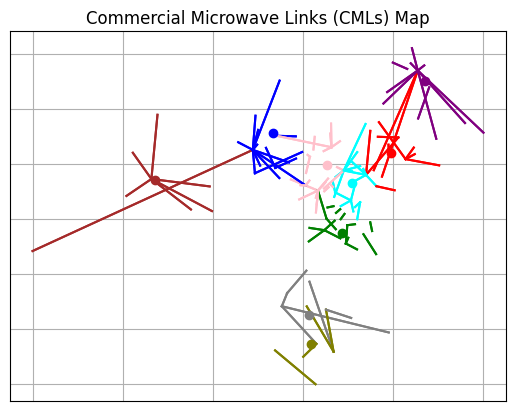

In [2]:
# ==========================================
# Hyper-parameters
# ==========================================
batch_size = 16
window_size = 32
rnn_n_features = 256
metadata_n_features = 32
n_layers = 2
lr = 1e-4
weight_decay = 1e-4
rnn_type = pnc.neural_networks.RNNType.GRU
n_epochs = 200
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ==========================================
# Dataset Loading
# ==========================================
time_slice = slice("2015-06-01", "2015-07-10")
dataset = pnc.datasets.loader_open_mrg_dataset(time_slice=time_slice)

# Compute Rain Statistics from Rain Gauges
rg = np.stack([p.data_array for p in dataset.point_set]).flatten()
param = scipy.stats.expon.fit(rg)
exp_gamma = param[1]

print("--- Rain Rate Statistics ---")
print(f"Mean[mm/hr]: {np.mean(rg):.4f}")
print(f"Std[mm/hr]: {np.std(rg):.4f}")
print(f"Percentage of wet samples: {100 * np.sum(rg > 0) / rg.size:.2f}%")
print(f"Percentage of dry samples: {100 * np.sum(rg == 0) / rg.size:.2f}%")
print(f"Exponential Distribution Parameters: {param}")

# Plotting Links
dataset.link_set.plot_links(scale=True, scale_factor=1.0)
plt.title("Commercial Microwave Links (CMLs) Map")
plt.grid()
plt.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
plt.show()

In [4]:
# Data Loaders Definition
training_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])
data_loader = torch.utils.data.DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

# Initialize the Two-Step RNN Network
model = pnc.scm.rain_estimation.two_step_network(
    n_layers=n_layers, 
    rnn_type=rnn_type, 
    normalization_cfg=pnc.training_helpers.compute_data_normalization(data_loader),
    rnn_input_size=180, 
    rnn_n_features=rnn_n_features, 
    metadata_input_size=2, 
    metadata_n_features=metadata_n_features,
    pretrained=False
).to(device)

# Loss Formulation
class RegressionLoss(torch.nn.Module):
    def __init__(self, in_gamma, gamma_s=0.9):
        super(RegressionLoss, self).__init__()
        self.in_gamma = in_gamma
        self.gamma_s = gamma_s

    def forward(self, input, target):
        delta = (target - input) ** 2
        w = 1 - self.gamma_s * torch.exp(-self.in_gamma * target)
        return torch.sum(torch.mean(w * delta, dim=0))

loss_function_rain_est = RegressionLoss(exp_gamma)
loss_function_wet_dry = torch.nn.BCELoss()

# Calculate initial lambda (Balancing between estimation and detection)
loss_est = 0
loss_detection = 0
with torch.no_grad():
    for rain_rate, rsl, tsl, metadata in data_loader:
        state = model.init_state(batch_size=rsl.shape[0])
        m_step = (math.floor(rain_rate.shape[1] / window_size)) - 1
        for step in range(m_step):
            _rr_future = rain_rate[:, step * window_size + 1:(step + 1) * window_size + 1, 0].float().to(device)
            _rsl = rsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            _tsl = tsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            
            rain_estimation_detection, state = model(torch.cat([_rsl, _tsl], dim=-1), metadata.to(device), state.detach())
            rain_hat = rain_estimation_detection[:, :, 0]
            rain_detection = rain_estimation_detection[:, :, 1]
            
            loss_est += loss_function_rain_est(rain_hat, _rr_future)
            loss_detection += loss_function_wet_dry(rain_detection, (_rr_future > 0.1).float())
        break # One batch is enough to set the scale

lambda_value = loss_detection / loss_est
print(f"Calculated Lambda Value: {lambda_value.item():.4f}")

Calculated Lambda Value: 0.1041


In [5]:
model_path = os.path.abspath("forecast_ws32_lr0.0001_rnn256.pth")

# Load or Train Model
if os.path.exists(model_path):
    print(f"Loading trained model from {model_path}...")
    ckpt = torch.load(model_path, map_location=device, weights_only=False)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)
    print("Model loaded successfully.")
else:
    print("No saved model found. Starting Training...")
    opt = torch.optim.RAdam(model.parameters(), lr=lr, weight_decay=weight_decay)
    model.train()
    
    for epoch in range(n_epochs):
        for rain_rate, rsl, tsl, metadata in tqdm(data_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            state = model.init_state(batch_size=rsl.shape[0])
            m_step = math.floor(rain_rate.shape[1] / window_size)
            for step in range(m_step):
                opt.zero_grad()
                _rr_future = rain_rate[:, step * window_size+1 : (step + 1) * window_size+1, 0].float().to(device)
                _rsl = rsl[:, step * window_size : (step + 1) * window_size, :].to(device)
                _tsl = tsl[:, step * window_size : (step + 1) * window_size, :].to(device)
                
                rain_estimation_detection, state = model(torch.cat([_rsl, _tsl], dim=-1), metadata.to(device), state.detach())
                
                rain_hat = rain_estimation_detection[:, :, 0]
                rain_detection = rain_estimation_detection[:, :, 1]
                
                loss_est = loss_function_rain_est(rain_hat, _rr_future)
                loss_det = loss_function_wet_dry(rain_detection, (_rr_future > 0.1).float())
                loss = lambda_value * loss_est + loss_det
                
                loss.backward()
                opt.step()
                
    torch.save({"model_state_dict": model.state_dict()}, model_path)
    print("Training finished and model saved.")

# ==========================================
# Generate Inference for All Links (res_ml)
# ==========================================
def infer_all_links(model, full_dataset, window_size, device):
    full_loader = torch.utils.data.DataLoader(full_dataset, batch_size=len(full_dataset), shuffle=False)
    model.eval()
    print("Inferring rain for all CMLs...")
    with torch.no_grad():
        for rain_rate, rsl, tsl, metadata in full_loader:
            state = model.init_state(batch_size=rsl.shape[0])
            m_step = math.floor(rain_rate.shape[1] / window_size)
            
            rain_hat_list = []
            for step in range(m_step):
                _rsl = rsl[:, step * window_size : (step + 1) * window_size, :].to(device)
                _tsl = tsl[:, step * window_size : (step + 1) * window_size, :].to(device)
                
                prediction, state = model(torch.cat([_rsl, _tsl], dim=-1), metadata.to(device), state.detach())
                # Mask output using the wet/dry detection
                rain_hat = prediction[:, :, 0] * torch.round(prediction[:, :, 1])
                rain_hat_list.append(rain_hat.cpu().numpy())
                
            # Concatenate time windows and transpose to (time_steps, num_links)
            res_ml = np.concatenate(rain_hat_list, axis=1).T
            break
    return res_ml

res_ml = infer_all_links(model, dataset, window_size, device)
print(f"Inference array created. Shape (Time, Links): {res_ml.shape}")


Loading trained model from C:\Users\after\FieldSense\projects\SY_Data_Driven\forecast_ws32_lr0.0001_rnn256.pth...
Model loaded successfully.
Inferring rain for all CMLs...
Inference array created. Shape (Time, Links): (3808, 214)


Generating IDW maps from CMLs...
Generating GMZ maps from CMLs...


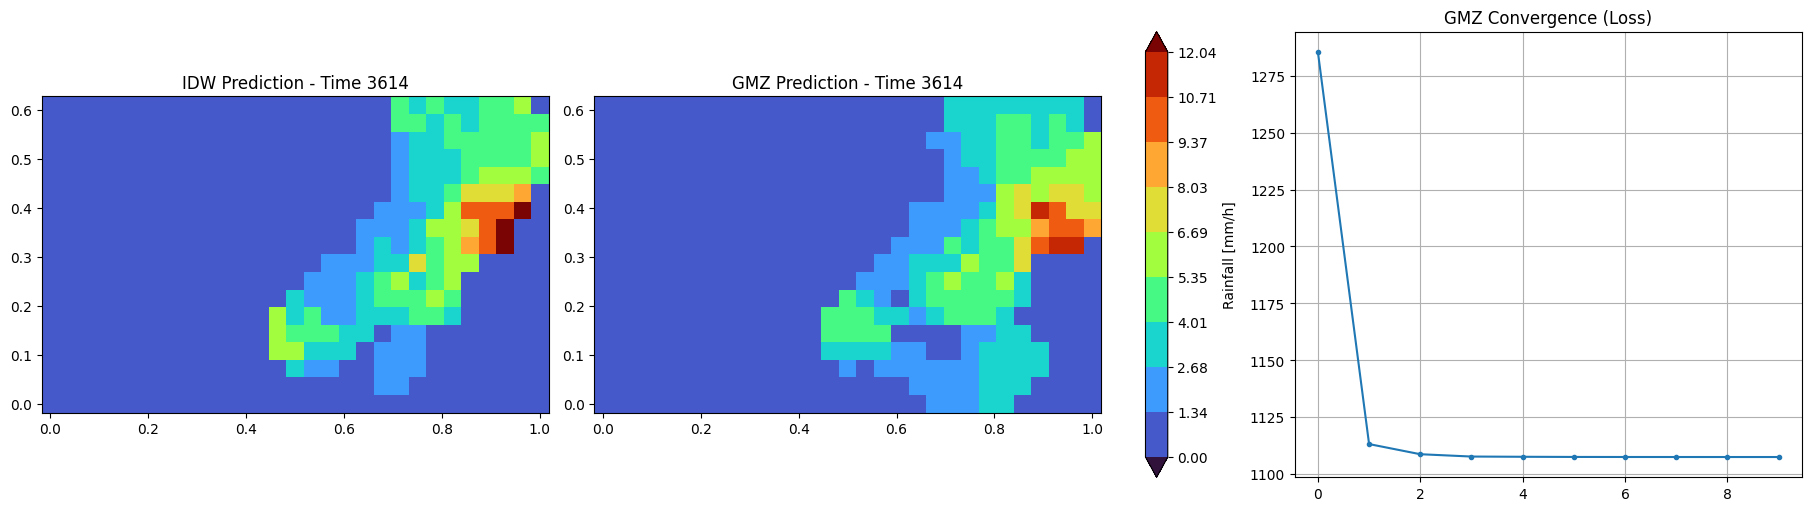

In [37]:
# ==========================================
# Map Generation (IDW & GMZ)
# ==========================================
region_of_interest = 3
point_per_link = 2

# המרת וקטור השערוכים ל-Tensor והיפוך ממדים (.T) כדי שיתאים ל-pynncml
res_ml_tensor = torch.tensor(res_ml, dtype=torch.float32).T

print("Generating IDW maps from CMLs...")
idw = pnc.mcm.generate_link_set_idw(dataset.link_set, roi=region_of_interest)
rain_map_idw = idw(res_ml_tensor).detach().cpu().numpy()

print("Generating GMZ maps from CMLs...")
gmz = pnc.mcm.generate_link_set_gmz(dataset.link_set, roi=region_of_interest, point_per_link=point_per_link)
gmz_out = gmz(res_ml_tensor)

# טיפול בפלט של ה-GMZ (מפה + שגיאות התכנסות)
if isinstance(gmz_out, tuple):
    rain_map_gmz = gmz_out[0].detach().cpu().numpy()
    
    if isinstance(gmz_out[1], torch.Tensor):
        losses = gmz_out[1].detach().cpu().numpy()
    else:
        losses = np.array(gmz_out[1])
else:
    rain_map_gmz = gmz_out.detach().cpu().numpy()
    losses = None

# ==========================================
# Validation & Plotting
# ==========================================
time_index = 3614  # אפשר לשנות את האינדקס כדי לראות זמנים שונים

# שימוש ב-constrained_layout=True כדי למנוע את השגיאה של ה-tight_layout
fig, ax = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# חישוב גבולות הצבעים (Color Bounds) לפי המקסימום של ה-IDW
peak_rain = np.max(rain_map_idw[time_index]) + 1
bounds = np.arange(0, peak_rain, max(peak_rain / 10, 0.1))
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='both')

# 1. מפת IDW
pc_zero = ax[0].pcolormesh(
    idw.x_grid_vector,
    idw.y_grid_vector,
    rain_map_idw[time_index, :, :].T,
    shading='nearest',
    cmap='turbo',
    norm=norm,
)
ax[0].set_title(f'IDW Prediction - Time {time_index}')
ax[0].set_aspect('equal', 'box')

# 2. מפת GMZ
pc_one = ax[1].pcolormesh(
    idw.x_grid_vector,
    idw.y_grid_vector,
    rain_map_gmz[time_index, :, :].T,
    shading='nearest',
    cmap='turbo',
    norm=norm,
)
ax[1].set_title(f'GMZ Prediction - Time {time_index}')
ax[1].set_aspect('equal', 'box')

# 3. גרף התכנסות ה-Loss של GMZ
if losses is not None and len(losses.shape) > 1:
    clean_losses = np.nan_to_num(losses[:, time_index], nan=0.0)
    ax[2].plot(clean_losses, marker='o', markersize=3)
    ax[2].set_title('GMZ Convergence (Loss)')
    ax[2].grid(True)
else:
    ax[2].text(0.5, 0.5, "No Loss Data", ha='center')

# הוספת סרגל צבעים (Colorbar) משותף
fig.colorbar(pc_one, ax=ax[0:2], label='Rainfall [mm/h]', fraction=0.03, pad=0.04)

# הפקודה plt.tight_layout() הוסרה מכיוון שהשתמשנו ב-constrained_layout
plt.show()

Verified 9 gauges.


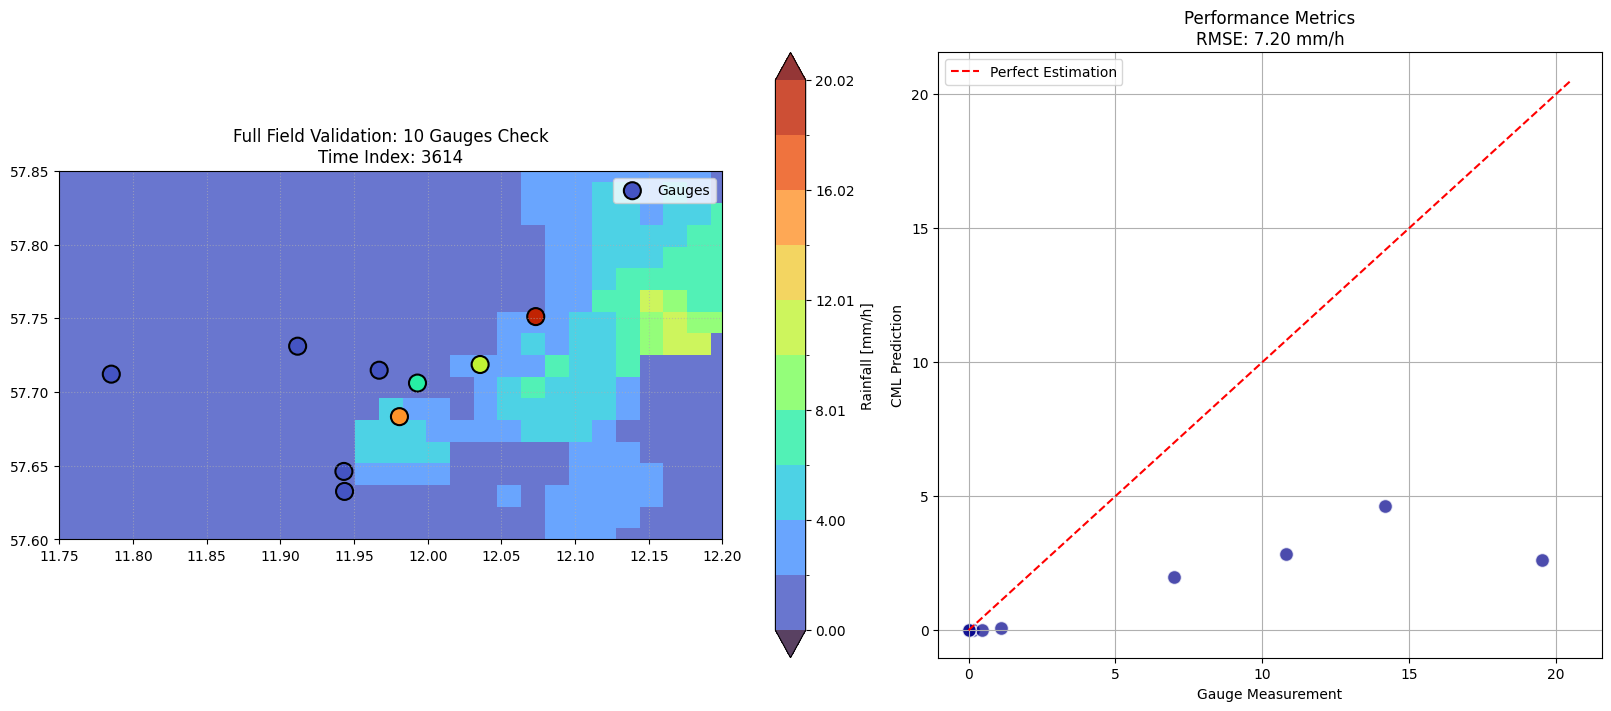

In [39]:
# ==========================================
# Point-to-Pixel Spatial Validation & Test Set Info
# ==========================================
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import colors
from sklearn.metrics import mean_squared_error, mean_absolute_error

def get_scalar(val):
    return float(np.asarray(val).flatten()[0])

# --- חלק א': הגדרת סט הבחינה ומציאת אירוע גשם משמעותי (מענה לדרור ויוסי) ---
print("--- Test Set & Event Documentation (For LaTeX Report) ---")
num_cmls = len(dataset.link_set.link_list)
num_rgs = len(dataset.point_set)
print(f"Number of Active CMLs: {num_cmls}")
print(f"Number of Rain Gauges (RGs) used: {num_rgs}")

# חילוץ תאריכים ומשך האירוע באופן מדויק מתוך הנתונים
try:
    time_vector = dataset.link_set.data.time.values
    exact_start = pd.to_datetime(time_vector[0])
    exact_end = pd.to_datetime(time_vector[-1])
    event_duration = exact_end - exact_start
    print(f"Start Date: {exact_start}")
    print(f"End Date: {exact_end}")
    print(f"Event Duration: {event_duration}")
except Exception as e:
    print(f"Time boundaries derived from slice: {time_slice}")

# יצירת מטריצה של כל מדי הגשם וחישוב הממוצע המרחבי לכל חלון זמן
rg_matrix = np.stack([p.data_array for p in dataset.point_set])
mean_rain_per_time = np.mean(rg_matrix, axis=0)

# הגדרה דינמית של best_time_index לפי חלון הזמן בו ירד הכי הרבה גשם בממוצע
best_time_index = int(np.argmax(mean_rain_per_time))
peak_mean_rain = mean_rain_per_time[best_time_index]
peak_max_rain = np.max(rg_matrix[:, best_time_index])

print(f"\n--- Significant Event Details (Time Index {best_time_index}) ---")
print(f"Peak Spatial Average Rain Rate: {peak_mean_rain:.2f} mm/h")
print(f"Peak Local Rain Rate (Max Gauge): {peak_max_rain:.2f} mm/h")
print("----------------------------------------------------------\n")


# --- חלק ב': ולידציה מרחבית חזותית וסטטיסטית (Point-to-Pixel) ---

# הרחבת הגבולות הגיאוגרפיים כדי לוודא שכל התחנות נכנסות
# הוספנו מרווח ביטחון (Padding) של 0.05 מעלות לכל כיוון
REAL_MIN_LON, REAL_MAX_LON = 11.75, 12.20
REAL_MIN_LAT, REAL_MAX_LAT = 57.60, 57.85

# שליפת המפה הספציפית לפי האינדקס של נקודת השיא
map_data = rain_map_gmz[best_time_index]
grid_x_real = np.linspace(REAL_MIN_LON, REAL_MAX_LON, map_data.shape[0])
grid_y_real = np.linspace(REAL_MIN_LAT, REAL_MAX_LAT, map_data.shape[1])

valid_rg_v, valid_model_v = [], []
all_plot_x, all_plot_y, all_plot_v = [], [], []

for p in dataset.point_set:
    plon, plat = None, None
    for attr in ['lon', 'longitude', 'x']:
        if hasattr(p, attr): plon = get_scalar(getattr(p, attr)); break
    for attr in ['lat', 'latitude', 'y']:
        if hasattr(p, attr): plat = get_scalar(getattr(p, attr)); break
        
    if plon is not None:
        val = get_scalar(p.data_array[best_time_index])
        all_plot_x.append(plon)
        all_plot_y.append(plat)
        all_plot_v.append(val)
        
        # דגימה מהמפה והתאמה למד הגשם (Point-to-Pixel)
        if (REAL_MIN_LON <= plon <= REAL_MAX_LON) and (REAL_MIN_LAT <= plat <= REAL_MAX_LAT):
            ix = np.argmin(np.abs(grid_x_real - plon))
            iy = np.argmin(np.abs(grid_y_real - plat))
            m_val = map_data[ix, iy]
            if not np.isnan(m_val):
                valid_rg_v.append(val)
                valid_model_v.append(m_val)

# תצוגה
fig, ax = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
max_v = max(np.nanmax(map_data), np.max(all_plot_v)) + 0.5
norm = colors.BoundaryNorm(np.linspace(0, max_v, 11), ncolors=256, extend='both')

# גרף 1: מפת הגשם (רקע) + מדי הגשם (נקודות)
pc = ax[0].pcolormesh(grid_x_real, grid_y_real, map_data.T, shading='nearest', cmap='turbo', norm=norm, alpha=0.8)
ax[0].scatter(all_plot_x, all_plot_y, c=all_plot_v, cmap='turbo', norm=norm, edgecolors='black', lw=1.5, s=150, label='Gauges')

ax[0].set_title(f'Full Field Validation: Gauges Check\nTime Index: {best_time_index}')
ax[0].set_aspect('equal')
ax[0].set_xlim(REAL_MIN_LON, REAL_MAX_LON)
ax[0].set_ylim(REAL_MIN_LAT, REAL_MAX_LAT)
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].legend()
fig.colorbar(pc, ax=ax[0], label='Rainfall [mm/h]')

# גרף 2: גרף הפיזור ומטריקת ה-RMSE
if len(valid_rg_v) > 0:
    v_rg, v_mod = np.array(valid_rg_v), np.array(valid_model_v)
    ax[1].scatter(v_rg, v_mod, c='darkblue', s=100, alpha=0.7, edgecolors='white')
    lim = max(v_rg.max(), v_mod.max()) + 1
    ax[1].plot([0, lim], [0, lim], 'r--', label='Perfect Estimation')
    ax[1].set_title(f'Performance Metrics\nRMSE: {np.sqrt(mean_squared_error(v_rg, v_mod)):.2f} mm/h')
    ax[1].set_xlabel('Gauge Measurement'); ax[1].set_ylabel('CML Prediction')
    ax[1].legend(); ax[1].grid(True)
    print(f"Verified {len(valid_rg_v)} gauges.")

plt.show()